In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import transforms
from torch.utils.data import DataLoader

from src.datasets.eurosat_dataset import EuroSATDataset

In [3]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [4]:
DATA_DIR = PROJECT_ROOT / "data"

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)

train_csv = (
    PROCESSED_DIR
    / "train_spatial.csv"
)

val_csv = (
    PROCESSED_DIR
    / "val_spatial.csv"
)

test_csv = (
    PROCESSED_DIR
    / "test_spatial.csv"
)

print(train_csv.exists())
print(val_csv.exists())
print(test_csv.exists())

True
True
True


In [5]:
EUROSAT_MEAN = (
    0.34437724,
    0.38029198,
    0.40777111
)

EUROSAT_STD = (
    0.20265734,
    0.13689059,
    0.11554374
)

In [6]:
train_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=EUROSAT_MEAN,
        std=EUROSAT_STD
    )
])

In [7]:
eval_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=EUROSAT_MEAN,
        std=EUROSAT_STD
    )
])

In [8]:
train_dataset = EuroSATDataset(
    train_csv,
    transform=train_transform
)

val_dataset = EuroSATDataset(
    val_csv,
    transform=eval_transform
)

test_dataset = EuroSATDataset(
    test_csv,
    transform=eval_transform
)

In [9]:
print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

print(
    "\nTotal:",
    len(train_dataset)
    + len(val_dataset)
    + len(test_dataset)
)

Train: 21568
Validation: 2774
Test: 2658

Total: 27000


In [10]:
sample_img, sample_label = train_dataset[0]

print(
    "Image Shape:",
    sample_img.shape
)

print(
    "Label:",
    sample_label
)

Image Shape: torch.Size([3, 224, 224])
Label: 0


In [11]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [12]:
images, labels = next(
    iter(train_loader)
)

print(
    "Images:",
    images.shape
)

print(
    "Labels:",
    labels.shape
)

print(
    "Dtype:",
    images.dtype
)

Images: torch.Size([64, 3, 224, 224])
Labels: torch.Size([64])
Dtype: torch.float32


In [13]:
def denormalize(image):

    mean = torch.tensor(
        EUROSAT_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        EUROSAT_STD
    ).view(3, 1, 1)

    image = image * std + mean

    image = torch.clamp(
        image,
        0,
        1
    )

    return image

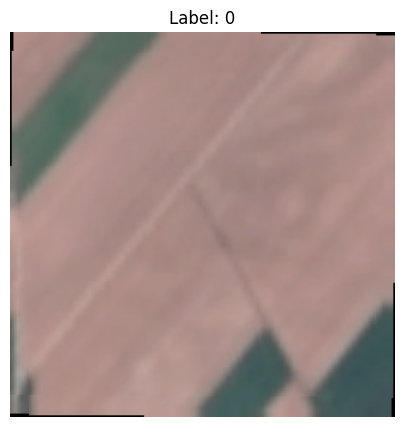

In [14]:
sample_img, sample_label = train_dataset[0]

img = denormalize(
    sample_img
)

img = (
    img.permute(1, 2, 0)
    .numpy()
)

plt.figure(figsize=(5,5))

plt.imshow(img)

plt.title(
    f"Label: {sample_label}"
)

plt.axis("off")

plt.show()

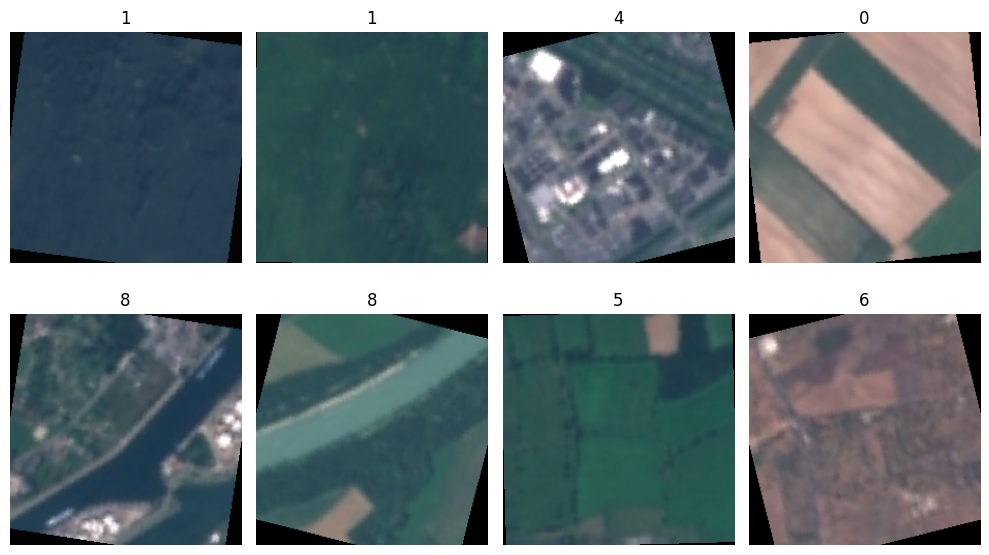

In [15]:
images, labels = next(
    iter(train_loader)
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(10, 6)
)

for i, ax in enumerate(
    axes.flatten()
):

    img = denormalize(
        images[i]
    )

    img = (
        img.permute(1, 2, 0)
        .numpy()
    )

    ax.imshow(img)

    ax.set_title(
        f"{labels[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()